## SETTING UP DOWNLOAD URL

### URL CREATION

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

# --------------------------------------------------
# 1. Setup
# --------------------------------------------------

BASE_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/citibike"
PERIOD = "202510"
file_name = f"JC-{PERIOD}-citibike-tripdata.zip"

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True)

zip_path = output_dir / file_name

# ---------------------------------------------c-----
# 2. Download one ZIP file
# --------------------------------------------------

url = f"{BASE_URL}/{file_name}"

print("downloading form:  ", url)
print("saving into:  ", zip_path)

### Downlaoding ZIP FILE

In [ ]:
urlretrieve(url,zip_path)

In [ ]:
with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Extracted files into: {output_dir}")

In [ ]:
zip_path.unlink()
print("ZIP file removed.")

### Downlaod All

In [ ]:
YEAR = [2025]
MONTH =  [str(i+1) if i+1>9 else "0" + str(i+1) for i in range(12)]

In [ ]:
def download_periods(year:list,start_m:int, stop_m:int)->list:
    """
    
    """
    YEAR = year
    MONTH =  [str(i+1) if i+1>9 else "0" + str(i+1) for i in range(start_m, stop_m)]

    periods = []

    for i in YEAR:
        for j in MONTH:
            k = i+j
            periods.append(k)
    print(periods)
    return periods



In [ ]:
download_periods(['2025'],10,12)

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

BASE_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/citibike"
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True)

periods = download_periods(['2025'],10,12)

print(periods)
for  period in periods:
    file_name = f"JC-{period}-citibike-tripdata.csv.zip"


    zip_path = output_dir / file_name
    url = f"{BASE_URL}/{file_name}"

    print("downloading form:  ", url)
    
    urlretrieve(url,zip_path)
    
    print("saving into:  ", zip_path)


    with ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_dir)


    print(f"Extracted files into: {output_dir}")

    zip_path.unlink()
    print("ZIP file removed.")



### Checking One 

In [1]:
import glob
import numpy as np
import pandas as pd

file_names = glob.glob('../data/citibike/*.csv')

file_names


['../data/citibike/JC-202511-citibike-tripdata.csv',
 '../data/citibike/JC-202507-citibike-tripdata.csv',
 '../data/citibike/JC-202505-citibike-tripdata.csv',
 '../data/citibike/JC-202503-citibike-tripdata.csv',
 '../data/citibike/JC-202509-citibike-tripdata.csv',
 '../data/citibike/JC-202501-citibike-tripdata.csv',
 '../data/citibike/JC-202506-citibike-tripdata.csv',
 '../data/citibike/JC-202510-citibike-tripdata.csv',
 '../data/citibike/JC-202504-citibike-tripdata.csv',
 '../data/citibike/JC-202512-citibike-tripdata.csv',
 '../data/citibike/JC-202502-citibike-tripdata.csv',
 '../data/citibike/JC-202508-citibike-tripdata.csv']

In [2]:
len(file_names)

12

In [3]:
dfs = []
cols = []
for file_name in file_names:
    df = pd.read_csv(file_name)
    print(file_name)
    print(df.columns, 2*"||",len(df.columns))

    cols.append(list(df.columns))
    dfs.append(df)




../data/citibike/JC-202511-citibike-tripdata.csv
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
../data/citibike/JC-202507-citibike-tripdata.csv
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
../data/citibike/JC-202505-citibike-tripdata.csv
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
../data/citibike/JC-202503-citibike-tripdata.csv
Index(['ride_id', 'rideable_type', 'sta

In [4]:
citibike_df = pd.concat(dfs)
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member


In [5]:
citibike_df.info()

<class 'pandas.DataFrame'>
Index: 1002704 entries, 0 to 108440
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1002704 non-null  str    
 1   rideable_type       1002704 non-null  str    
 2   started_at          1002704 non-null  str    
 3   ended_at            1002704 non-null  str    
 4   start_station_name  1002701 non-null  str    
 5   start_station_id    1002701 non-null  str    
 6   end_station_name    999469 non-null   str    
 7   end_station_id      998307 non-null   str    
 8   start_lat           1002702 non-null  float64
 9   start_lng           1002702 non-null  float64
 10  end_lat             999260 non-null   float64
 11  end_lng             999260 non-null   float64
 12  member_casual       1002704 non-null  str    
dtypes: float64(4), str(9)
memory usage: 230.1 MB


In [6]:
citibike_df.shape

(1002704, 13)

### Forcing Dates

In [7]:
citibike_df.info()

<class 'pandas.DataFrame'>
Index: 1002704 entries, 0 to 108440
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1002704 non-null  str    
 1   rideable_type       1002704 non-null  str    
 2   started_at          1002704 non-null  str    
 3   ended_at            1002704 non-null  str    
 4   start_station_name  1002701 non-null  str    
 5   start_station_id    1002701 non-null  str    
 6   end_station_name    999469 non-null   str    
 7   end_station_id      998307 non-null   str    
 8   start_lat           1002702 non-null  float64
 9   start_lng           1002702 non-null  float64
 10  end_lat             999260 non-null   float64
 11  end_lng             999260 non-null   float64
 12  member_casual       1002704 non-null  str    
dtypes: float64(4), str(9)
memory usage: 230.1 MB


In [8]:
citibike_df['started_at'] = pd.to_datetime(citibike_df['started_at'],errors="coerce")
citibike_df['ended_at'] = pd.to_datetime(citibike_df['ended_at'],errors="coerce")

citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member


In [9]:
citibike_df.info()

<class 'pandas.DataFrame'>
Index: 1002704 entries, 0 to 108440
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             1002704 non-null  str           
 1   rideable_type       1002704 non-null  str           
 2   started_at          1002704 non-null  datetime64[us]
 3   ended_at            1002704 non-null  datetime64[us]
 4   start_station_name  1002701 non-null  str           
 5   start_station_id    1002701 non-null  str           
 6   end_station_name    999469 non-null   str           
 7   end_station_id      998307 non-null   str           
 8   start_lat           1002702 non-null  float64       
 9   start_lng           1002702 non-null  float64       
 10  end_lat             999260 non-null   float64       
 11  end_lng             999260 non-null   float64       
 12  member_casual       1002704 non-null  str           
dtypes: datetime64[us](2), float64

### Handling the missing values

In [10]:
citibike_df.shape

(1002704, 13)

In [11]:
missing_values = (
    citibike_df
    .isna()
    .sum()
    .reset_index()
)

missing_values.columns = ["column", "missing_count"]

missing_values["missing_share"] = (
    missing_values["missing_count"] / len(citibike_df)
)

missing_values.sort_values("missing_count", ascending=False)

,column,missing_count,missing_share
7,end_station_id,4397,0.004385
10,end_lat,3444,0.003435
11,end_lng,3444,0.003435
6,end_station_name,3235,0.003226
4,start_station_name,3,0.000003
5,start_station_id,3,0.000003
8,start_lat,2,0.000002
9,start_lng,2,0.000002
0,ride_id,0,0.000000
1,rideable_type,0,0.000000


In [12]:
citibike_df = citibike_df.dropna(
    subset=[
        "ride_id",
        "started_at",
        "ended_at",
        "start_lat",
        "start_lng",
        "end_lat",
        "end_lng"
    ]
)

In [13]:
citibike_df.shape

(999258, 13)

### Ride Duration

Removing extremes

In [14]:
citibike_df["ride_duration_minutes"] = (
    citibike_df["ended_at"] - citibike_df["started_at"]
).dt.total_seconds() / 60

In [15]:
citibike_df = citibike_df[
    (citibike_df["ride_duration_minutes"] > 1) &
    (citibike_df["ride_duration_minutes"] <= 24 * 60)
].copy()

In [16]:
citibike_df.shape

(999225, 14)

### Time Based Variables

In [17]:
citibike_df["date"] = citibike_df["started_at"].dt.date
citibike_df["month"] = citibike_df["started_at"].dt.to_period("M").astype(str)
citibike_df["month_name"] = citibike_df["started_at"].dt.month_name()
citibike_df["day_of_week"] = citibike_df["started_at"].dt.day_name()
citibike_df["hour"] = citibike_df["started_at"].dt.hour

In [18]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,Tuesday,18
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,Wednesday,16
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,Tuesday,22
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,Saturday,6
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,Monday,20


In [19]:
def assign_season(month_number):
    if month_number in [12, 1, 2]:
        return "Winter"
    elif month_number in [3, 4, 5]:
        return "Spring"
    elif month_number in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


citibike_df["season"] = (
    citibike_df["started_at"]
    .dt.month
    .apply(assign_season)
)

In [20]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,Monday,20,Autumn


In [21]:
citibike_df.to_csv('../data/citibike/JC/JC2025_Enriched.csv',index=False)

# ATTENTION, IN CASE YOU IMPORT CSV MAKE SURE TO PARCE THE DATES

In [22]:
citibike_df.shape

(999225, 20)

In [23]:
citibike_df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'ride_duration_minutes', 'date', 'month', 'month_name',
       'day_of_week', 'hour', 'season'],
      dtype='str')

In [24]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,Monday,20,Autumn


In [25]:
monthly_rides = (
    citibike_df
    .groupby("month", as_index=False)
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

monthly_rides

,month,number_of_rides
0,2024-12,2
1,2025-01,50589
2,2025-02,45250
3,2025-03,73277
4,2025-04,81533
5,2025-05,93202
6,2025-06,96736
7,2025-07,107374
8,2025-08,108001
9,2025-09,115580


## Weather Data | API

In [2]:
import pandas as pd
import requests

lat = 40.7178
lng = -74.0431

start_date = "2025-01-01"
end_date = "2025-12-31"

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lng,
    "start_date": start_date,
    "end_date": end_date,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
        "rain_sum",
        "snowfall_sum",
        "wind_speed_10m_max"
    ],
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()



weather_daily = pd.DataFrame(data["daily"])
weather_daily["date"] = pd.to_datetime(weather_daily["time"])
weather_daily = weather_daily.drop(columns="time")

weather_daily.tail()

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,date
360,-1.0,-7.3,-3.6,5.3,0.4,3.43,16.3,2025-12-27
361,1.0,-11.6,-5.8,0.9,0.9,0.00,9.4,2025-12-28
362,7.3,-1.4,3.5,3.9,3.9,0.00,23.8,2025-12-29
363,-0.2,-3.0,-1.3,0.0,0.0,0.00,25.5,2025-12-30
364,-0.2,-3.7,-2.2,0.0,0.0,0.00,16.5,2025-12-31


In [3]:
list(weather_daily.columns)

['temperature_2m_max',
 'temperature_2m_min',
 'temperature_2m_mean',
 'precipitation_sum',
 'rain_sum',
 'snowfall_sum',
 'wind_speed_10m_max',
 'date']

In [4]:
weather_daily = weather_daily[['date','temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max'
       ]]

weather_daily.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,10.9,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.3,-3.6,-2.2,0.0,0.0,0.0,19.9


In [7]:
weather_daily.to_csv('../data/citibike/JC/jersey_weather_2025.csv', index = False)

### Whether Analytics

You can continue from here

In [8]:
weather_daily = pd.read_csv('../data/citibike/JC/jersey_weather_2025.csv')
citibike_df = pd.read_csv('../data/citibike/JC/JC2025_Enriched.csv')

In [9]:
citibike_df['date'] = pd.to_datetime(citibike_df['date'], errors='coerce')

In [10]:
citibike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999225 entries, 0 to 999224
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ride_id                999225 non-null  str           
 1   rideable_type          999225 non-null  str           
 2   started_at             999225 non-null  str           
 3   ended_at               999225 non-null  str           
 4   start_station_name     999224 non-null  str           
 5   start_station_id       999224 non-null  str           
 6   end_station_name       998439 non-null  str           
 7   end_station_id         998282 non-null  str           
 8   start_lat              999225 non-null  float64       
 9   start_lng              999225 non-null  float64       
 10  end_lat                999225 non-null  float64       
 11  end_lng                999225 non-null  float64       
 12  member_casual          999225 non-null  str           


In [11]:
weather_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 365 non-null    str    
 1   temperature_2m_max   365 non-null    float64
 2   temperature_2m_min   365 non-null    float64
 3   temperature_2m_mean  365 non-null    float64
 4   precipitation_sum    365 non-null    float64
 5   rain_sum             365 non-null    float64
 6   snowfall_sum         365 non-null    float64
 7   wind_speed_10m_max   365 non-null    float64
dtypes: float64(7), str(1)
memory usage: 26.5 KB


### Merging

In [12]:
daily_rides = (
    citibike_df
    .groupby("date", as_index=False)
    .agg(
        number_of_rides=("ride_id", "count")
    )
)
daily_rides["date"] = pd.to_datetime(daily_rides["date"])
daily_rides


,date,number_of_rides
0,2024-12-31,2
1,2025-01-01,1179
2,2025-01-02,1710
3,2025-01-03,1770
4,2025-01-04,1337
...,...,...
361,2025-12-27,287
362,2025-12-28,488
363,2025-12-29,952
364,2025-12-30,1142


In [13]:
bike_weather_daily = daily_rides.merge(
    weather_daily,
    on="date",
    how="left"
)
bike_weather_daily

ValueError: You are trying to merge on datetime64[us] and str columns for key 'date'. If you wish to proceed you should use pd.concat

In [14]:
import plotly.express as px
fig = px.line(
    weather_daily,
    x="date",
    y="temperature_2m_mean",
    title="Daily Average Temperature Over Time",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Average Temperature",
    hovermode="x unified"
)

fig.show()

In [15]:
weather_daily.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,10.9,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.3,-3.6,-2.2,0.0,0.0,0.0,19.9


In [16]:
import plotly.express as px
fig = px.line(
    weather_daily,
    x="date",
    y="wind_speed_10m_max",
    title="Daily Maximum Wind Spead Over Time",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Wind Speed km/h",
    hovermode="x unified"
)

fig.show()

In [17]:
temperature_long = weather_daily.melt(
    id_vars= 'date',
    value_vars =  [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean"
    ],
    var_name =  "temperature_type",
    value_name = "temperature"
)

temperature_long

,date,temperature_type,temperature
0,2025-01-01,temperature_2m_max,10.9
1,2025-01-02,temperature_2m_max,5.4
2,2025-01-03,temperature_2m_max,3.2
3,2025-01-04,temperature_2m_max,-0.1
4,2025-01-05,temperature_2m_max,0.3
...,...,...,...
1090,2025-12-27,temperature_2m_mean,-3.6
1091,2025-12-28,temperature_2m_mean,-5.8
1092,2025-12-29,temperature_2m_mean,3.5
1093,2025-12-30,temperature_2m_mean,-1.3


In [18]:
fig = px.line(
    temperature_long,
    x="date",
    y="temperature",
    color="temperature_type",
    title="Daily Temperature: Maximum, Minimum, and Average",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Temperature",
    # hovermode="x unified"
)

fig.show()

In [19]:
weather_daily.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,10.9,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.3,-3.6,-2.2,0.0,0.0,0.0,19.9


In [20]:
season_rides = (
    citibike_df
    .groupby("season", as_index=False)
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]

season_rides["season"] = pd.Categorical(
    season_rides["season"],
    categories=season_order,
    ordered=True
)

season_rides = season_rides.sort_values("season")

season_rides

,season,number_of_rides
3,Winter,143703
1,Spring,248012
2,Summer,312111
0,Autumn,295399


In [21]:
fig = px.bar(
    season_rides,
    x="season",
    y="number_of_rides",
    title="Number of Citi Bike Rides per Season",
    text_auto=True
)

fig.update_layout(
    xaxis_title="Season",
    yaxis_title="Number of Rides"
)

fig.show()

In [22]:
top_start_stations = (
    citibike_df
    .dropna(subset=["start_station_name"])
    .groupby("start_station_name", as_index=False)
    .agg(
        number_of_departures=("ride_id", "count")
    )
    .sort_values("number_of_departures", ascending=False)
    .head(10)
)

top_start_stations

,start_station_name,number_of_departures
52,Grove St PATH,45004
58,Hoboken Terminal - Hudson St & Hudson Pl,25889
53,Hamilton Park,22259
95,River St & Newark St,21383
86,Newport PATH,20663
18,Bergen Ave & Sip Ave,20398
44,Exchange Pl,20008
0,11 St & Washington St,19481
94,River St & 1 St,19143
87,Newport Pkwy,18720


In [23]:
top_end_stations = (
    citibike_df
    .dropna(subset=["end_station_name"])
    .groupby("end_station_name", as_index=False)
    .agg(
        number_of_arrivals=("ride_id", "count")
    )
    .sort_values("number_of_arrivals", ascending=False)
    .head(10)
)

top_end_stations

,end_station_name,number_of_arrivals
232,Grove St PATH,47758
241,Hoboken Terminal - Hudson St & Hudson Pl,26639
233,Hamilton Park,22353
347,River St & Newark St,22113
317,Newport PATH,20701
73,Bergen Ave & Sip Ave,20368
207,Exchange Pl,20160
7,11 St & Washington St,19505
318,Newport Pkwy,18707
346,River St & 1 St,18515


In [24]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,Monday,20,Autumn


In [25]:
top_end_stations = (
    citibike_df
    # .dropna(subset=["end_station_name"])
    .groupby(["start_station_name","end_station_name"], as_index=False)
    .agg(
        number_of_arrivals=("ride_id", "count")
    )
    .sort_values("number_of_arrivals", ascending=False)
    .head(10)
)

top_end_stations

,start_station_name,end_station_name,number_of_arrivals
5218,Hoboken Terminal - Hudson St & Hudson Pl,Hoboken Ave at Monmouth St,4559
6944,McGinley Square,Bergen Ave & Sip Ave,4310
4544,Grove St PATH,Marin Light Rail,4131
6750,Marin Light Rail,Grove St PATH,3832
4537,Grove St PATH,Liberty Light Rail,3750
1823,Bergen Ave & Sip Ave,McGinley Square,3609
6132,Liberty Light Rail,Grove St PATH,3605
5125,Hoboken Ave at Monmouth St,Hoboken Terminal - Hudson St & Hudson Pl,3257
2186,Brunswick St,Grove St PATH,3178
4636,Hamilton Park,Grove St PATH,3000


In [26]:
fig = px.bar(
    top_start_stations.sort_values("number_of_departures"),
    x="number_of_departures",
    y="start_station_name",
    orientation="h",
    title="Top 10 Start Stations by Number of Departures",
    text_auto=True
)

fig.update_layout(
    xaxis_title="Number of Departures",
    yaxis_title="Start Station"
)

fig.show()

In [27]:
fig = px.bar(
    top_end_stations.sort_values("number_of_arrivals"),
    x="number_of_arrivals",
    y="end_station_name",
    orientation="h",
    title="Top 10 End Stations by Number of Arrivals",
    text_auto=True
)

fig.update_layout(
    xaxis_title="Number of Arrivals",
    yaxis_title="End Station"
)

fig.show()


In [28]:
fig = px.scatter(
    bike_weather_daily,
    x="temperature_2m_mean",
    y="number_of_rides",
    trendline="ols",
    title="Daily Rides vs Average Temperature"
)

fig.update_layout(
    xaxis_title="Average Daily Temperature",
    yaxis_title="Number of Rides"
)

fig.show()

NameError: name 'bike_weather_daily' is not defined

In [29]:
fig = px.scatter(
    bike_weather_daily,
    x="wind_speed_10m_max",
    y="number_of_rides",
    trendline="ols",
    title="Daily Rides vs Maximum Wind Speed"
)

fig.update_layout(
    xaxis_title="Maximum Wind Speed",
    yaxis_title="Number of Rides"
)

fig.show()

NameError: name 'bike_weather_daily' is not defined

In [30]:
fig = px.scatter(
    bike_weather_daily,
    x="precipitation_sum",
    y="number_of_rides",
    trendline="ols",
    title="Daily Rides vs Precipitation"
)

fig.update_layout(
    xaxis_title="Daily Precipitation",
    yaxis_title="Number of Rides"
)

fig.show()

NameError: name 'bike_weather_daily' is not defined

In [31]:
import plotly.graph_objects as go


fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=bike_weather_daily["date"],
        y=bike_weather_daily["number_of_rides"],
        mode="lines",
        name="Daily Rides",
        yaxis="y1"
    )
)

fig.add_trace(
    go.Scatter(
        x=bike_weather_daily["date"],
        y=bike_weather_daily["temperature_2m_mean"],
        mode="lines",
        name="Daily Average Temperature",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Daily Rides and Daily Average Temperature",
    xaxis=dict(
        title="Day"
    ),
    yaxis=dict(
        title="Daily Rides",
        side="left"
    ),
    yaxis2=dict(
        title="Daily Average Temperature",
        overlaying="y",
        side="right"
    ),
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()

NameError: name 'bike_weather_daily' is not defined

## Geopandas


In [63]:
import geopandas as gpd
from urllib.parse import urlencode
from pathlib import Path


url = '../data/citibike/jersey-city-neighborhoods.geojson'

jersey_city = gpd.read_file(url)

jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


<Axes: >

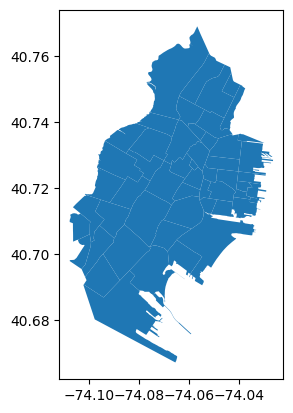

In [49]:
jersey_city.plot()

In [78]:
customers = pd.DataFrame({
    "customer_id": [1, 2, 3, 4],
    "customer_name": ["Anna", "David", "Mariam", "Arman"],
    "city": ["Yerevan", "Gyumri", "Yerevan", "Vanadzor"]
})

orders = pd.DataFrame({
    "order_id": [101, 102, 103, 104, 105],
    "customer_id": [1, 2, 2, 3, 5],
    "order_amount": [25000, 18000, 42000, 15000, 30000]
})


In [ ]:
customers.merge()